In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Business Understanding
The main goal is to analyze and visualize data from the Stack Overflow Developer Survey

### Data Understanding

In [4]:
def load_and_prepare_data(file_path):
    """
    Load data from CSV file and prepare it for analysis.
    
    Args:
    file_path (str): Path to the CSV file.
    
    Returns:
    pd.DataFrame: Loaded and prepared DataFrame.
    """
    df = pd.read_csv(file_path)
    return df

In [5]:
df = load_and_prepare_data('./survey_results_public.csv')
df.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


In [45]:
#The current shape of our dataframe
df.shape

(89184, 84)

In [7]:
#We print all the columns available in our dataframe
df.columns

Index(['ResponseId', 'Q120', 'MainBranch', 'Age', 'Employment', 'RemoteWork',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType',
       'OrgSize', 'PurchaseInfluence', 'TechList', 'BuyNewTool', 'Country',
       'Currency', 'CompTotal', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith',
       'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith',
       'NEWCollabToolsWantToWorkWith', 'OpSysPersonal use',
       'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith',
       'OfficeStackAsyncWantToWorkWith', 'OfficeStackSyncHaveWorkedWith',
       'OfficeStackSyncWantToWorkWith', 'AISearchHaveWorkedWith',
       'AISearchWan

### Salary and Job Satisfaction


a. what’s the ratio of developers in each field

b. What are the most used programming languages by full-stack developers?

c. How do different job positions correlate with salary levels and job roles in the tech industry?

In [12]:
df.describe()

,ResponseId,CompTotal,WorkExp,ConvertedCompYearly
count,89184.000000,4.822500e+04,43579.000000,4.801900e+04
mean,44592.500000,1.036807e+42,11.405126,1.031101e+05
std,25745.347541,2.276847e+44,9.051989,6.814188e+05
min,1.000000,0.000000e+00,0.000000,1.000000e+00
25%,22296.750000,6.300000e+04,5.000000,4.390700e+04
50%,44592.500000,1.150000e+05,9.000000,7.496300e+04
75%,66888.250000,2.300000e+05,16.000000,1.216410e+05
max,89184.000000,5.000000e+46,50.000000,7.435143e+07


In [19]:
#df.set_index('ResponseId', inplace= True)
df.head()

,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
ResponseId,,,,,,,,,,,,,,,,,,,,,
1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,Other,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,NaN,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,NaN,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,Other;Codecademy;edX,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


###  Visualization

In [6]:
def set_plot_style():
    """Set the default style for plots."""
    sns.set_style('darkgrid')
    plt.rcParams['font.size'] = 14
    plt.rcParams['figure.figsize'] = (9, 5)
    plt.rcParams['figure.facecolor'] = '#00000000'

In [7]:
set_plot_style()

In [8]:
len(df[df['Country'].notna()]['Country'].unique())

185

In [9]:
df[df['Country'].notna()]['Country'].value_counts()[:10]

United States of America                                18647
Germany                                                  7328
India                                                    5625
United Kingdom of Great Britain and Northern Ireland     5552
Canada                                                   3507
France                                                   2933
Poland                                                   2435
Netherlands                                              2383
Australia                                                2078
Brazil                                                   2042
Name: Country, dtype: int64

In [10]:
def analyze_countries(df):
    """
    Analyze and plot country-related data.
    
    Args:
    df (pd.DataFrame): Input DataFrame.
    """
    top_countries = df['Country'].value_counts().head(10)
    plt.figure(figsize=(15, 6))
    plt.title("Countries with most response")
    sns.barplot(y=top_countries.index, x=top_countries)
    plt.ylabel("Number of Responses")
    plt.show()

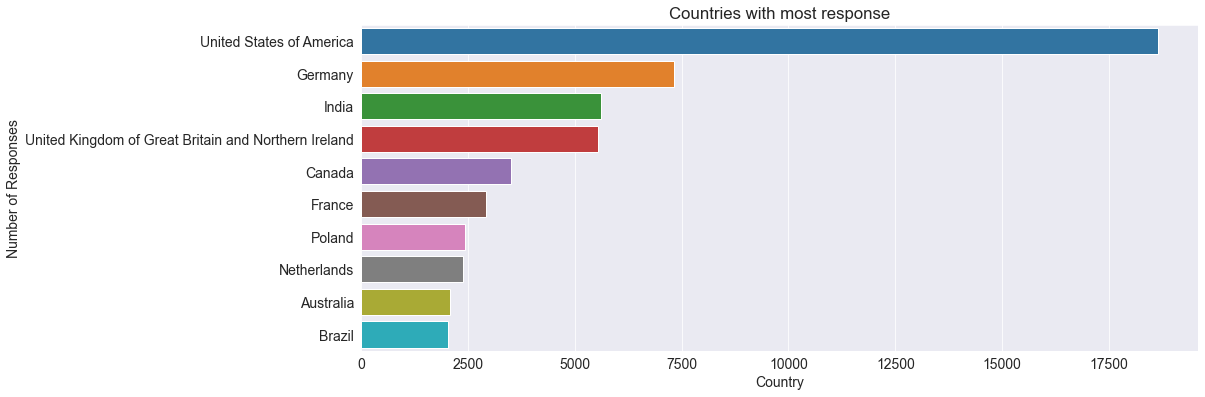

In [11]:
analyze_countries(df)

In [12]:
def analyze_education(df):
    """
    Analyze and plot education-related data.
    
    Args:
    df (pd.DataFrame): Input DataFrame.
    """
    top_education = df['EdLevel'].value_counts().head(10)
    plt.figure(figsize=(15, 6))
    plt.xticks(rotation=75)
    plt.title("Respondents' level of education")
    sns.barplot(y=top_education.index, x=top_education)
    plt.ylabel("Number of Responses")
    plt.show()

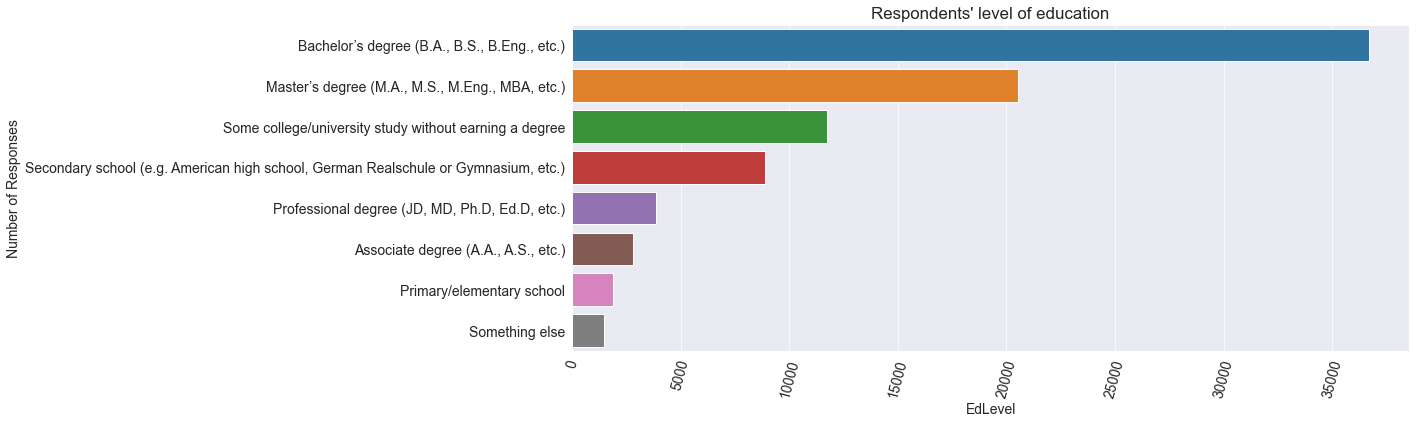

In [13]:
analyze_education(df)

In [14]:
def analyze_developer_types(df):
    """
    Analyze and plot developer type data.
    
    Args:
    df (pd.DataFrame): Input DataFrame.
    """
    top_dev_type = df['DevType'].value_counts()
    plt.figure(figsize=(12, 16))
    plt.xlabel("Percent %")
    sns.barplot(x=top_dev_type, y=top_dev_type.index)
    plt.title("Ratio of Developers in 2023")
    plt.show()

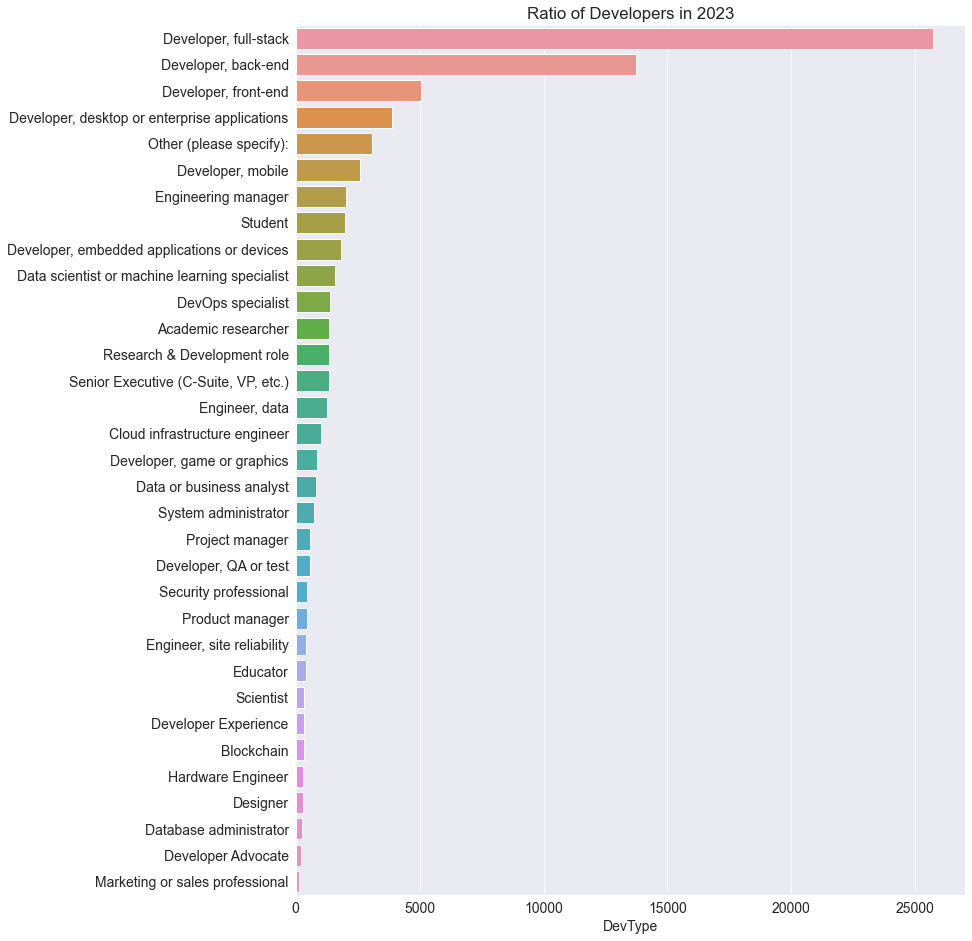

In [15]:
analyze_developer_types(df)

In [16]:
set(df['DevType'].tolist())

{'Academic researcher',
 'Blockchain',
 'Cloud infrastructure engineer',
 'Data or business analyst',
 'Data scientist or machine learning specialist',
 'Database administrator',
 'Designer',
 'DevOps specialist',
 'Developer Advocate',
 'Developer Experience',
 'Developer, QA or test',
 'Developer, back-end',
 'Developer, desktop or enterprise applications',
 'Developer, embedded applications or devices',
 'Developer, front-end',
 'Developer, full-stack',
 'Developer, game or graphics',
 'Developer, mobile',
 'Educator',
 'Engineer, data',
 'Engineer, site reliability',
 'Engineering manager',
 'Hardware Engineer',
 'Marketing or sales professional',
 'Other (please specify):',
 'Product manager',
 'Project manager',
 'Research & Development role',
 'Scientist',
 'Security professional',
 'Senior Executive (C-Suite, VP, etc.)',
 'Student',
 'System administrator',
 nan}

In [18]:
def analyze_languages_by_dev_type(df, dev_types):
    """
    Analyze and plot programming languages used by different developer types.
    
    Args:
    df (pd.DataFrame): Input DataFrame.
    dev_types (list): List of developer types to analyze.
    """
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 15))
    axes = axes.flatten()

    for i, column in enumerate(dev_types):
        temp = df[df['DevType'] == column]
        language_df = temp['LanguageHaveWorkedWith'].str.get_dummies(sep=';').sum().sort_values(ascending=False)[:10]
        
        sns.barplot(x=language_df, y=language_df.index, ax=axes[i])
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Languages used') 

    plt.tight_layout()
    plt.show()

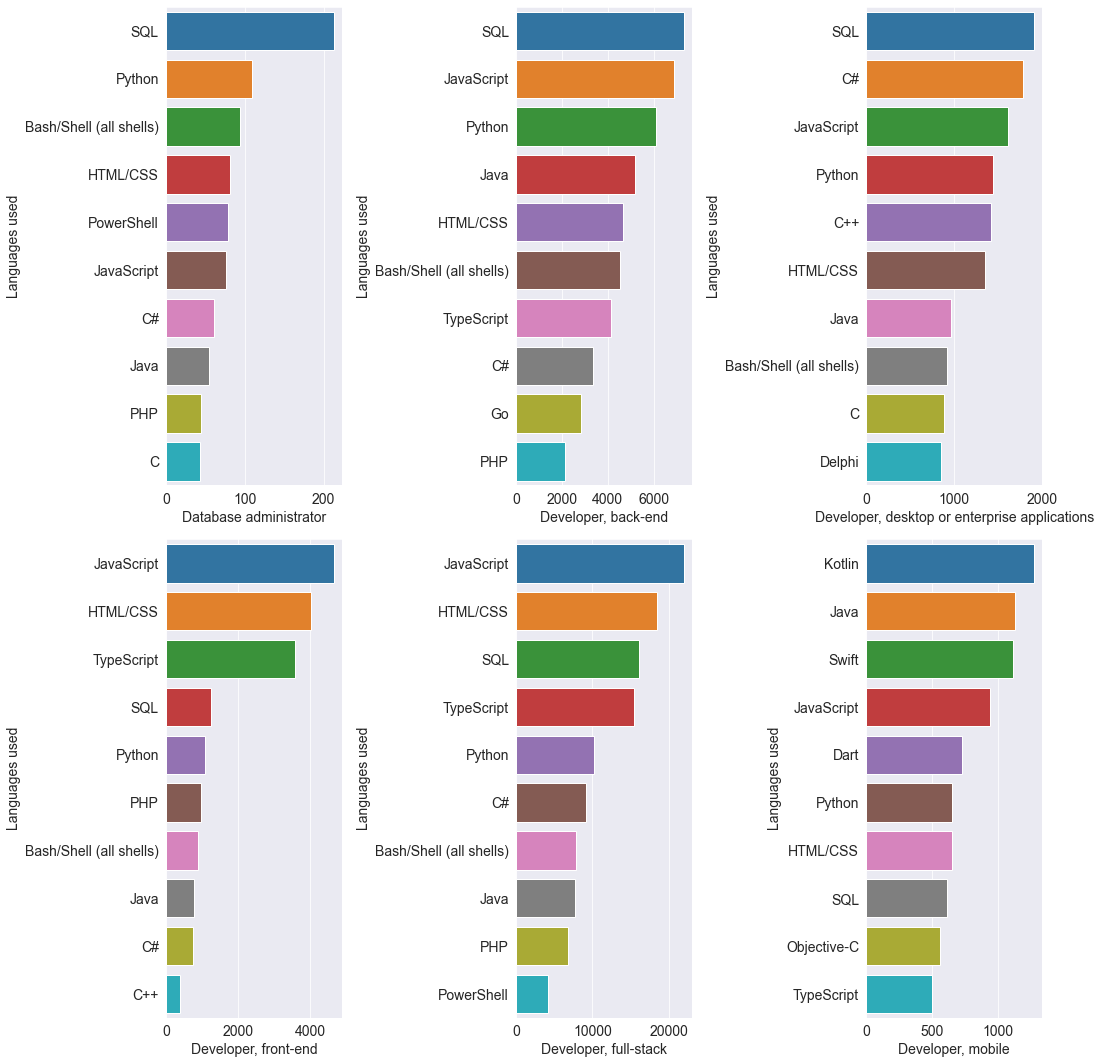

In [20]:
devList = ['Database administrator', 'Developer, back-end', 'Developer, desktop or enterprise applications', 'Developer, front-end', 'Developer, full-stack', 'Developer, mobile']
analyze_languages_by_dev_type(df, devList)

In [21]:
df['Currency'].isnull().sum()

23850

In [22]:
def analyze_salary_by_dev_type(df, dev_types):
    """
    Analyze and plot median salary by developer type.
    
    Args:
    df (pd.DataFrame): Input DataFrame.
    dev_types (list): List of developer types to analyze.
    """
    cleaned_sal_df = df.dropna(subset=['ConvertedCompYearly', 'DevType'])
    cleaned_sal_df = cleaned_sal_df.loc[cleaned_sal_df['DevType'].isin(dev_types)]
    cleaned_sal_df = cleaned_sal_df[cleaned_sal_df['DevType'] != 'Other (please specify):']

    group_df = cleaned_sal_df.groupby(['DevType'])['ConvertedCompYearly'].median().reset_index()
    group_df.sort_values(['ConvertedCompYearly'], ascending=False, inplace=True)
    group_df = group_df.reset_index()

    plt.figure(figsize=(20,10))
    ax = sns.barplot(x=group_df['ConvertedCompYearly'], y=group_df['DevType'])
    ax.bar_label(ax.containers[0])
    ax.set_xlabel('Median annual compensation', fontsize=15)
    ax.set_ylabel('Developer job roles', fontsize=15)
    plt.title('Median yearly salary (USD)', fontsize=20)
    plt.show()

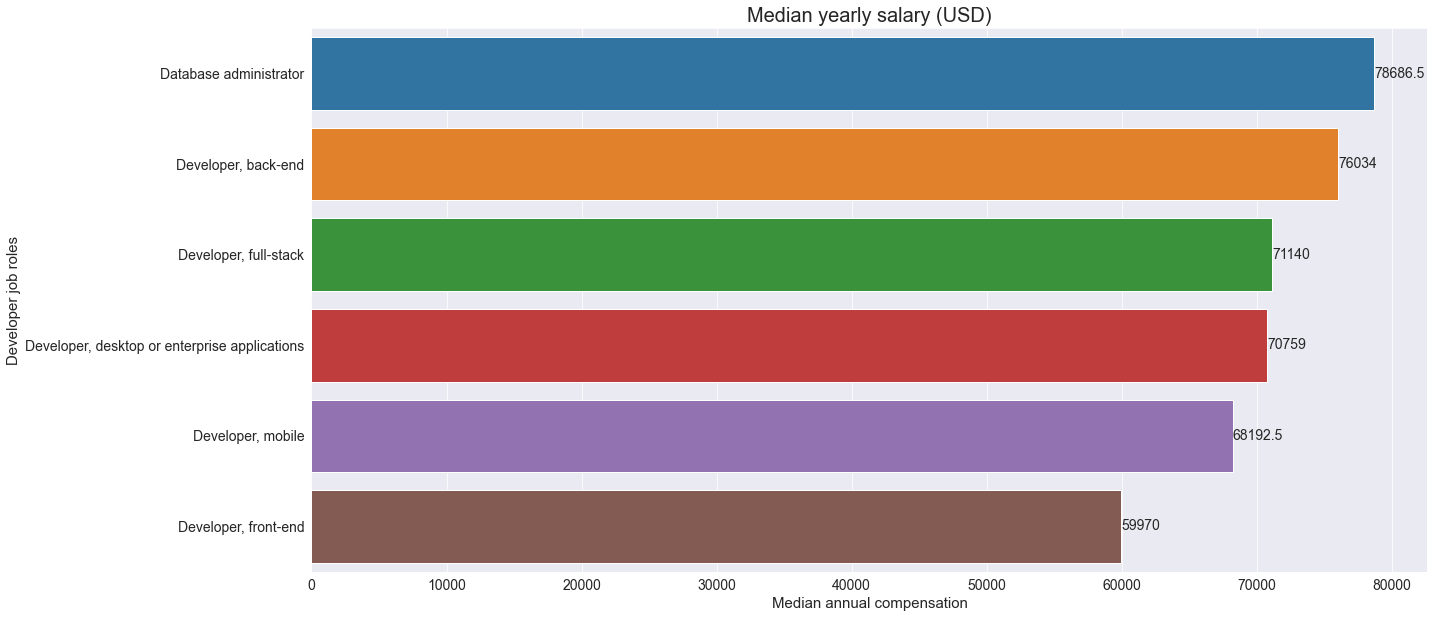

In [23]:
analyze_salary_by_dev_type(df, devList)

In [24]:
def analyze_salary_by_country_and_dev_type(df, dev_types):
    """
    Analyze and plot median salary by country for different developer types.
    
    Args:
    df (pd.DataFrame): Input DataFrame.
    dev_types (list): List of developer types to analyze.
    """
    cleaned_sal_df = df.dropna(subset=['ConvertedCompYearly', 'DevType', 'Country'])
    cleaned_sal_df.replace('United Kingdom of Great Britain and Northern Ireland', 'UK & North Ireland', inplace=True)

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 15))
    axes = axes.flatten()

    for i, column in enumerate(dev_types):
        temp = cleaned_sal_df[cleaned_sal_df['DevType'] == column]
        group_df = temp.groupby(['Country'])['ConvertedCompYearly'].median().reset_index()
        group_df.sort_values(['ConvertedCompYearly'], ascending=False, inplace=True)
        group_df = group_df[:10]
        
        sns.barplot(y=group_df['Country'], x=group_df['ConvertedCompYearly'], ax=axes[i])
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Median yearly salary (USD)') 

    plt.tight_layout()
    plt.show()

C:\Users\rewandji\AppData\Local\Temp\ipykernel_4732\3492552011.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_sal_df.replace('United Kingdom of Great Britain and Northern Ireland', 'UK & North Ireland', inplace=True)


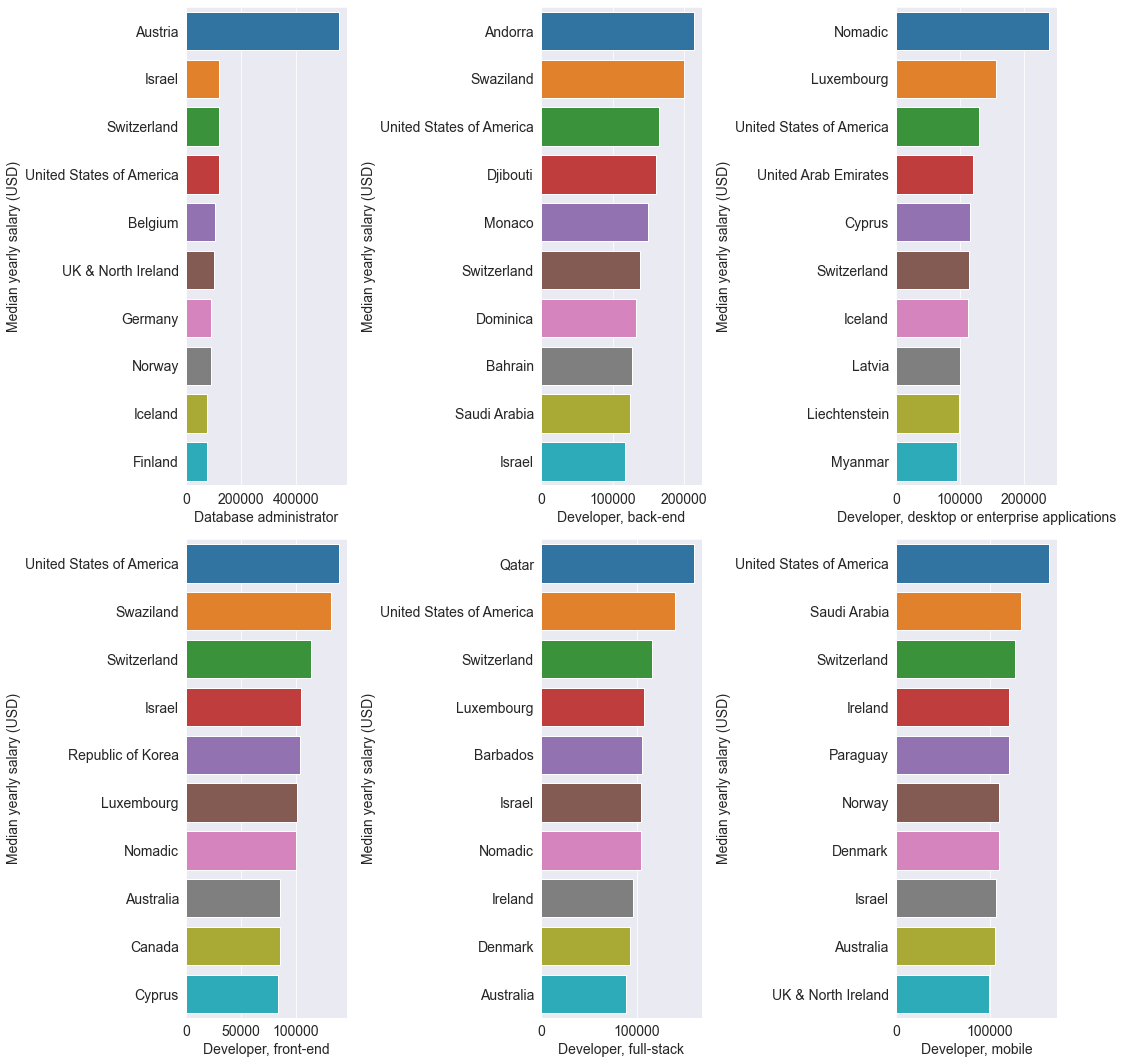

In [25]:
analyze_salary_by_country_and_dev_type(df, devList)